In [ ]:
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from Helpers.entsoe2 import fetch_entsoe_data
from Helpers.n_trim import drop_buses
from Helpers.zones import assign_zones
from Helpers.load_weighting import load_weight
from Helpers.production_weighting import production_weight, storage_weight
from Helpers.drop_buses import drop_buses
from Helpers.DC_links_add import DC_links_add
from Helpers.Add_key_generators import add_other_generators_Nordic, add_ror_generators_NO, add_ccgt_generators_NO
from Helpers.Plotting import plot_network_with_loadings, plot_network_simple, plot_network_bus_names
from Helpers.Loading_lines_and_links_relative_quantified import loading_lines_and_links_relative_quantified
from Helpers.Merge_technologies import merge_technologies
from Helpers.DK_1_cleanup import dk_1_cleanup
from Helpers.Distribute_generation_load import distribute_generation_load
from Helpers.Capacity_check_per_zone import capacity_check_per_zone
from Helpers.DC_links_modifications_power_distr import dc_links_modifications_power_distr
from Helpers.Add_slack_generators import add_slack_generators
from Helpers.ZoneFlowPlot import zoneFlowPlot
import os

1. Importing nordic grid from pypsa eur ex DC links to non-nordic countries. Plotting the imported network. 

<frozen importlib._bootstrap>:488: RuntimeWarning:

numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject

INFO:pypsa.network.io:New version 1.0.5 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores
C:\Users\aleks\AppData\Local\Temp\ipykernel_34532\101420152.py:2: DeprecatedWarning:

plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.



{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x216f0fc27b0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x216f2df05f0>,
  'Line': <matplotlib.collections.LineCollection at 0x216f11ebc80>},
 'flows': {}}

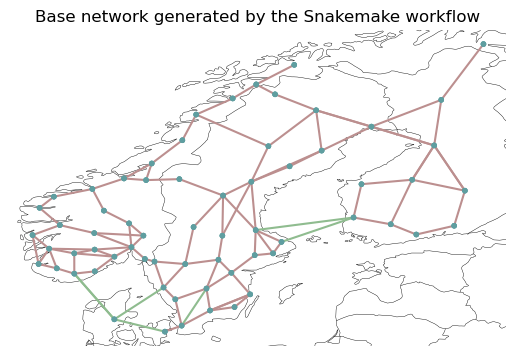

In [2]:
n = pypsa.Network("winter_base_s_65_elec_.nc")
n.plot(title="Base network generated by the Snakemake workflow")

2. Assign zone column to loads. Drop H2 and battery buses. Adding generators with carrier 'other' to every bus, and 'ror' to NO_3 and NO_4. Adding load_Weight for buses and producdtion weight for generators.

✅ Added 65 new 'other' PQ generators.
Found 6 buses in NO_3
Found 6 buses in NO_4
Found 5 buses in NO_1
Found 8 buses in NO_2


c:\Users\aleks\Documents\UsN\FM4017 - Project\FM4017-Project Repo Aleks\FM4017-Project\Plotting.py:175: DeprecatedWarning:

plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.



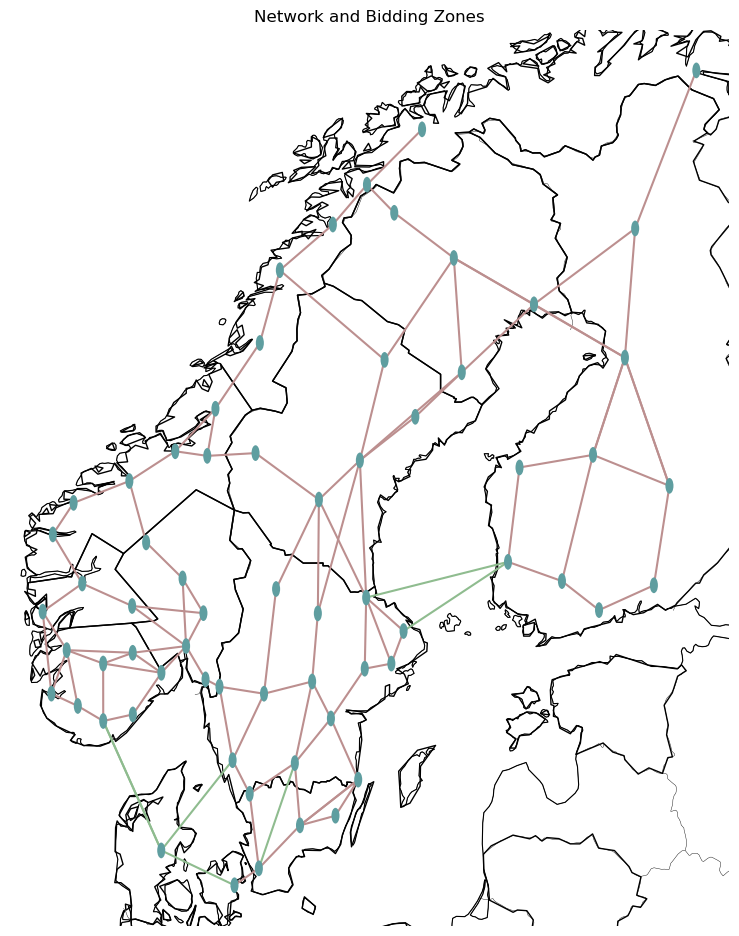

In [3]:
n = assign_zones(n)
drop_buses(n)
add_other_generators_Nordic(n)
add_ror_generators_NO(n)
add_ccgt_generators_NO(n)       #This is not really necessary. Small power and didnt affect accuracy of model. 
load_weight(n, snapshot_number=17, alpha=1) #Alpha is a constant used to alter how much load is placed at each node. Large alpha -> larger weight to higly loaded buses in pypsa set. Alpha = 1 gives proportional weight. 
production_weight(n)
storage_weight(n)
plot_network_simple(n)

3. Remove all loads and generators connected to the node in west denmark and add a slack generator.

In [4]:
dk_1_cleanup(n)

Found 1 buses in DK_1 zone
Removed 10 generators from DK0 0
Removed 1 loads from DK0 0
✅ Added slack generator to DK0 0


4. Fetch the ENTSOE-E data regarding AC flow, DC flow, load and production per bidding zone. Can be very time consuming, think about wether you need to do this or not. 
Use this if you want to collect data from other dates. Set run_fetch_entsoe = True if you want to run API call.
Use load from csv cells if you do not want to use other dates. 

In [5]:
run_fetch_entsoe = False
if run_fetch_entsoe:
    loads_df, gens_df, ac_flows_df, dc_flows_df = fetch_entsoe_data(start_date="2023-07-03", timezone="Europe/Oslo")
    loads_df.to_csv("loads_df_summer.csv")
    gens_df.to_csv("gens_df_summer.csv")
    ac_flows_df.to_csv("ac_flows_df_summer.csv")
    dc_flows_df.to_csv("dc_flows_df_summer.csv")
    season = "summer"

#Use save_multiindex_csv and load_multiindex_csv to save and load DataFrames with MultiIndex columns. Load we use anyways. Save you use if you want to save the data you collect using API. 
def save_multiindex_csv(df, filename):
    df.to_csv(filename, index=True)

def load_multiindex_csv(filename):
    return pd.read_csv(filename, header=[0, 1], index_col=0, parse_dates=True)

In [6]:
season = "summer"  # Change to "summer" for summer data, change to some random string if you want to use user specific data. 
if season == "winter":
    loads_df = pd.read_csv("loads_df_winter.csv", index_col=0, parse_dates=True)
    ac_flows_df = pd.read_csv("ac_flows_df_winter.csv", index_col=0, parse_dates=True)
    dc_flows_df = pd.read_csv("dc_flows_df_winter.csv", index_col=0, parse_dates=True)
    gens_df = load_multiindex_csv("gens_df_winter.csv")
    n.set_snapshots(gens_df.index)

elif season == "summer":
    loads_df = pd.read_csv("loads_df_summer.csv", index_col=0, parse_dates=True)
    ac_flows_df = pd.read_csv("ac_flows_df_summer.csv", index_col=0, parse_dates=True)
    dc_flows_df = pd.read_csv("dc_flows_df_summer.csv", index_col=0, parse_dates=True)
    gens_df = load_multiindex_csv("gens_df_summer.csv")
    n.set_snapshots(gens_df.index)

else: 
    loads_df = pd.read_csv("loads_df_user_specific.csv", index_col=0, parse_dates=True)
    ac_flows_df = pd.read_csv("ac_flows_df_user_specific.csv", index_col=0, parse_dates=True)
    dc_flows_df = pd.read_csv("dc_flows_df_user_specificr.csv", index_col=0, parse_dates=True)
    gens_df = load_multiindex_csv("gens_df_user_specific.csv")
    n.set_snapshots(gens_df.index)

print("You have chosen {} data.".format(season))

You have chosen summer data.


5. Merging technologies that couldnt be distributed into Technology: "Other" in gens_df. Needs to be done after you have a dataframe for generation. 

In [7]:
merge_technologies(gens_df, print_what_is_done=False)

6. Add nodes with a slack generator per country. Add slack to SE1 16 for Forsmark.

In [8]:
add_slack_generators(n, nordic_slack_bus='SE1 16', nordic_slack_name=f"slack_Forsmark")

 Added buses: ['DE', 'NL', 'GB', 'PL', 'LT', 'EE']
Added slack_Forsmark to Nordic area at bus SE1 16


7. Add DC links between nordic and non-nordic countries

In [9]:
DC_links_add(n, r"links_needed.csv")

Index(['relation/8184629-300-DC'], dtype='object')
Index(['relation/8184629-300-DC'], dtype='object')


Missing buses: {'way/24534144', 'way/98216482'}


PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 71
 - Carrier: 25
 - Generator: 466
 - Line: 101
 - Link: 15
 - Load: 64
 - StorageUnit: 62
Snapshots: 24

Checking capacity for each technology for each bidding zone. 

In [10]:
capacity_check_per_zone(n)

save_loading = False
if save_loading:
    capacity_gen, capacity_storage = capacity_check_per_zone(n)
    capacity_gen.to_csv("Result_generator_capacity.csv", index=True)
    capacity_storage.to_csv("Result_storage_units_capacity.csv", index=True)

CCGT
PHS
biomass
ccgt
coal
hydro
nuclear
offwind-ac
offwind-dc
offwind-float
oil
onwind
other
ror
slack
solar
solar-hsat

Total technologies: 17

Generators capacity (MW) by zone and technology:
carrier    CCGT  biomass   ccgt    coal  nuclear  offwind-ac  offwind-dc  \
zone                                                                       
DK_2     1038.0    311.0    0.0  1266.0      0.0      1050.0         0.0   
FI       2709.6   3226.9    0.0  1661.8   4362.0        73.0         0.0   
NO_1        0.0      0.0  250.0     0.0      0.0         0.0         0.0   
NO_2        0.0      0.0  400.0     0.0      0.0        50.0         0.0   
NO_3        0.0      0.0    0.0     0.0      0.0         0.0         0.0   
NO_4      459.0      0.0    0.0     0.0      0.0         0.0         0.0   
NO_5      294.0      0.0    0.0     0.0      0.0        88.0         0.0   
SE_1        0.0     35.0    0.0     0.0      0.0        10.3         0.0   
SE_2        0.0    245.0    0.0     0.0      

Lots of stuff. Mapping ENTSO-E to carrier. Distributing generation and loads based of weighting factor. 

In [11]:
distribute_generation_load(n, gens_df, loads_df)

✅ distributed: Zone=DK_2 Tech=Biomass Units=1
✅ distributed: Zone=DK_2 Tech=Fossil Gas Units=1
✅ distributed: Zone=DK_2 Tech=Fossil Hard coal Units=1
✅ distributed: Zone=DK_2 Tech=Solar Units=2
✅ distributed: Zone=DK_2 Tech=Wind Offshore Units=3
✅ distributed: Zone=DK_2 Tech=Wind Onshore Units=1
✅ distributed: Zone=FI Tech=Biomass Units=9
✅ distributed: Zone=FI Tech=Fossil Gas Units=7
✅ distributed: Zone=FI Tech=Fossil Hard coal Units=4
✅ distributed: Zone=FI Tech=Hydro Run-of-river and poundage Units=7
✅ distributed: Zone=FI Tech=Nuclear Units=2
✅ distributed: Zone=FI Tech=Other Units=9
✅ distributed: Zone=FI Tech=Solar Units=16
✅ distributed: Zone=FI Tech=Wind Onshore Units=9
✅ distributed: Zone=NO_1 Tech=Fossil Gas Units=5
✅ distributed: Zone=NO_1 Tech=Hydro Run-of-river and poundage Units=2
✅ distributed: Zone=NO_1 Tech=Wind Onshore Units=5
✅ distributed: Zone=NO_2 Tech=Fossil Gas Units=8
✅ distributed: Zone=NO_2 Tech=Hydro Run-of-river and poundage Units=1
✅ distributed: Zone=NO_2

c:\Users\aleks\Documents\UsN\FM4017 - Project\FM4017-Project Repo Aleks\FM4017-Project\Distribute_generation_load.py:196: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.

c:\Users\aleks\Documents\UsN\FM4017 - Project\FM4017-Project Repo Aleks\FM4017-Project\Distribute_generation_load.py:207: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



Checking how large the difference between the actual production and the distributed production is. For quality control and adjustment of distribution function. If diff is large, user needs to look at the distribution of generation. 

In [12]:
expected_vals = gens_df.sum(axis=1)
actual_vals = n.generators_t.p_set.sum(axis=1) + n.storage_units_t.p_set.clip(lower=0).sum(axis=1)
diff = actual_vals - expected_vals
diff


#print(gens_df)

snapshot
2023-07-03 00:00:00   -8.000000e-02
2023-07-03 01:00:00   -9.000000e-02
2023-07-03 02:00:00   -1.000000e-01
2023-07-03 03:00:00   -1.100000e-01
2023-07-03 04:00:00   -1.100000e-01
2023-07-03 05:00:00   -8.000000e-02
2023-07-03 06:00:00   -7.000000e-02
2023-07-03 07:00:00   -3.000000e-02
2023-07-03 08:00:00   -3.000000e-02
2023-07-03 09:00:00   -1.000000e-02
2023-07-03 10:00:00   -2.000000e-02
2023-07-03 11:00:00   -3.000000e-02
2023-07-03 12:00:00    7.275958e-12
2023-07-03 13:00:00   -2.000000e-02
2023-07-03 14:00:00   -4.000000e-02
2023-07-03 15:00:00   -4.000000e-02
2023-07-03 16:00:00   -6.000000e-02
2023-07-03 17:00:00   -4.000000e-02
2023-07-03 18:00:00   -6.000000e-02
2023-07-03 19:00:00   -2.000000e-02
2023-07-03 20:00:00   -5.000000e-02
2023-07-03 21:00:00   -4.000000e-02
2023-07-03 22:00:00   -4.000000e-02
2023-07-03 23:00:00   -2.000000e-02
dtype: float64

Checking how large the difference between the actual load and the distributed load is. For quality control and adjustment of distribution function. If diff is large, user needs to look at the distribution of load. 

In [13]:
expected_vals = loads_df.sum(axis=1)
actual_vals = n.loads_t.p_set.sum(axis=1)
diff = actual_vals - expected_vals
diff

snapshot
2023-07-03 00:00:00   -7.275958e-12
2023-07-03 01:00:00    7.275958e-12
2023-07-03 02:00:00   -3.637979e-12
2023-07-03 03:00:00    0.000000e+00
2023-07-03 04:00:00   -1.091394e-11
2023-07-03 05:00:00   -1.455192e-11
2023-07-03 06:00:00   -1.091394e-11
2023-07-03 07:00:00    7.275958e-12
2023-07-03 08:00:00    0.000000e+00
2023-07-03 09:00:00   -1.455192e-11
2023-07-03 10:00:00    7.275958e-12
2023-07-03 11:00:00   -1.455192e-11
2023-07-03 12:00:00    1.455192e-11
2023-07-03 13:00:00   -7.275958e-12
2023-07-03 14:00:00    7.275958e-12
2023-07-03 15:00:00   -1.455192e-11
2023-07-03 16:00:00   -7.275958e-12
2023-07-03 17:00:00    2.182787e-11
2023-07-03 18:00:00    0.000000e+00
2023-07-03 19:00:00    0.000000e+00
2023-07-03 20:00:00    0.000000e+00
2023-07-03 21:00:00    0.000000e+00
2023-07-03 22:00:00    7.275958e-12
2023-07-03 23:00:00   -1.091394e-11
dtype: float64

DC-link stuff happening below. Modification of existing DC links and setting power transfer for each snapshot. 

In [14]:
dc_links_modifications_power_distr(n, dc_flows_df)

Column DK_1<->NL not found in network links.
Column SE_3<->SE_4 not found in network links.
False
Column DK_1<->NL not found in network links.
Column SE_3<->SE_4 not found in network links.


Plotting map with bus names

c:\Users\aleks\Documents\UsN\FM4017 - Project\FM4017-Project Repo Aleks\FM4017-Project\Plotting.py:189: DeprecatedWarning:

plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.



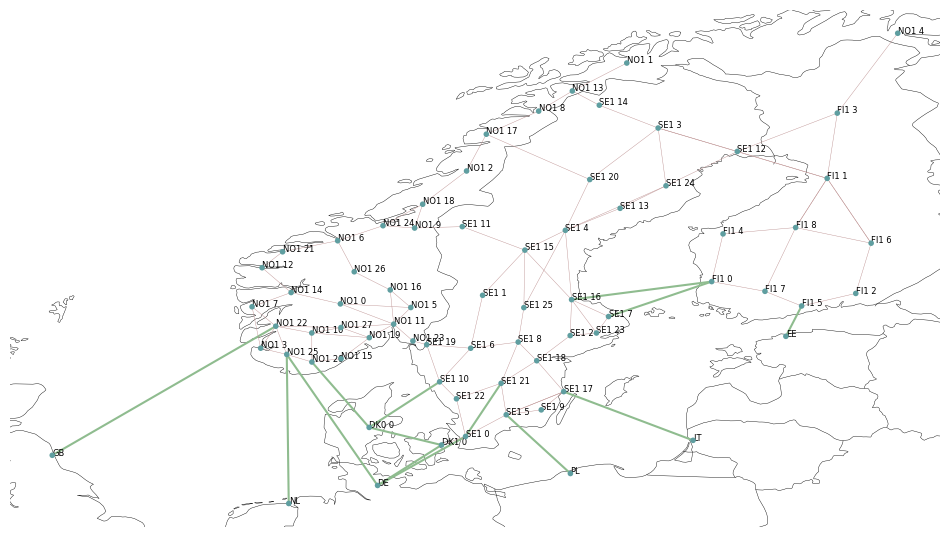

In [15]:

plot_network_bus_names(n)

If we get a new dataset for winter this cell needs to go. There is 0 cb flow in the snapshot from ENTSO-E. Line was maybe under maintanance? We could use this startegy to check N-1 (or what if scenario) as well.
Code cell which can be used to deactivate certain lines for e.g. contingency analysis.  

In [16]:
if season == "winter":
    #print(n.lines.loc['57'])
    n.lines.loc["57", "active"] = False
    #n.lines.loc["42", "active"] = False
    print(n.lines.loc['57', ["bus0", "bus1", "active"]])
    #print(n.lines.loc['58', ["bus0", "bus1", "active"]])
     

Doing power flow calculation

In [17]:
n.lpf()

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x00000216E4FE8560> for snapshot(s) DatetimeIndex(['2023-07-03 00:00:00', '2023-07-03 01:00:00',
               '2023-07-03 02:00:00', '2023-07-03 03:00:00',
               '2023-07-03 04:00:00', '2023-07-03 05:00:00',
               '2023-07-03 06:00:00', '2023-07-03 07:00:00',
               '2023-07-03 08:00:00', '2023-07-03 09:00:00',
               '2023-07-03 10:00:00', '2023-07-03 11:00:00',
               '2023-07-03 12:00:00', '2023-07-03 13:00:00',
               '2023-07-03 14:00:00', '2023-07-03 15:00:00',
               '2023-07-03 16:00:00', '2023-07-03 17:00:00',
               '2023-07-03 18:00:00', '2023-07-03 19:00:00',
               '2023-07-03 20:00:00', '2023-07-03 21:00:00',
               '2023-07-03 22:00:00', '2023-07-03 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', freq=None)
INFO:pypsa.network.power_flow:Performing linear load

Displaying line and link relative loading [%], loading [MW] and capacity [MW].

In [18]:
pd.set_option('display.width', None)           # Don't wrap lines
pd.set_option('display.max_columns', None)     # Show all columns
pd.set_option('display.max_colwidth', None)    # Don't truncate long strings
pd.set_option('display.colheader_justify', 'left')  # Align headers neatly
pd.set_option('display.expand_frame_repr', False)   # Keep one-line rows
loading_lines_and_links_relative_quantified(n, snapshot_number=17, number_of_displayed_links=len(n.links), number_of_displayed_lines=15)

save_loading = False
if save_loading:
    loading_lines, loading_links = loading_lines_and_links_relative_quantified(n, snapshot_number=17, number_of_displayed_links=len(n.links), number_of_displayed_lines=15)
    loading_lines.to_csv("Result_loading_lines_summer.csv", index=True)
    loading_links.to_csv("Result_loading_links_summer.csv", index=True)
pd.reset_option('all')


 Zero loaded components:
Zero-loaded AC Lines: 0
Zero-loaded HVDC Links: 1

 AC lines loading
    bus0    zone_bus0 bus1    zone_bus1  loading_percent  loading_MW   rated_capacity_MW type    
2     FI1 0    FI       FI1 7    FI      38.632378        2762.178593  7149.905734        AC Line
100   SE1 6  SE_3       SE1 8  SE_3      34.830478         622.586584  1787.476433        AC Line
60    SE1 0  SE_4      SE1 22  SE_4      33.423749        1194.883281  3574.952867        AC Line
91   SE1 21  SE_3      SE1 22  SE_4      32.862592         587.411089  1787.476433        AC Line
42   NO1 17  NO_4      SE1 20  SE_2      31.972064         157.160604   491.556019        AC Line
65   SE1 10  SE_3      SE1 22  SE_4      26.093771        1865.680005  7149.905734        AC Line
86   SE1 18  SE_3       SE1 8  SE_3      25.569347         457.046057  1787.476433        AC Line
28   NO1 11  NO_1      NO1 23  NO_1      23.654617        1125.760131  4759.156004        AC Line
40   NO1 17  NO_4      

C:\Users\aleks\AppData\Local\Temp\ipykernel_34532\232733342.py:13: FutureWarning:

data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.

C:\Users\aleks\AppData\Local\Temp\ipykernel_34532\232733342.py:13: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

C:\Users\aleks\AppData\Local\Temp\ipykernel_34532\232733342.py:13: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



Plotting the network with bidding zones, line loading and link loading. Arrows indicates power flow direction. 

c:\Users\aleks\Documents\UsN\FM4017 - Project\FM4017-Project Repo Aleks\FM4017-Project\Plotting.py:53: DeprecatedWarning:

plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.



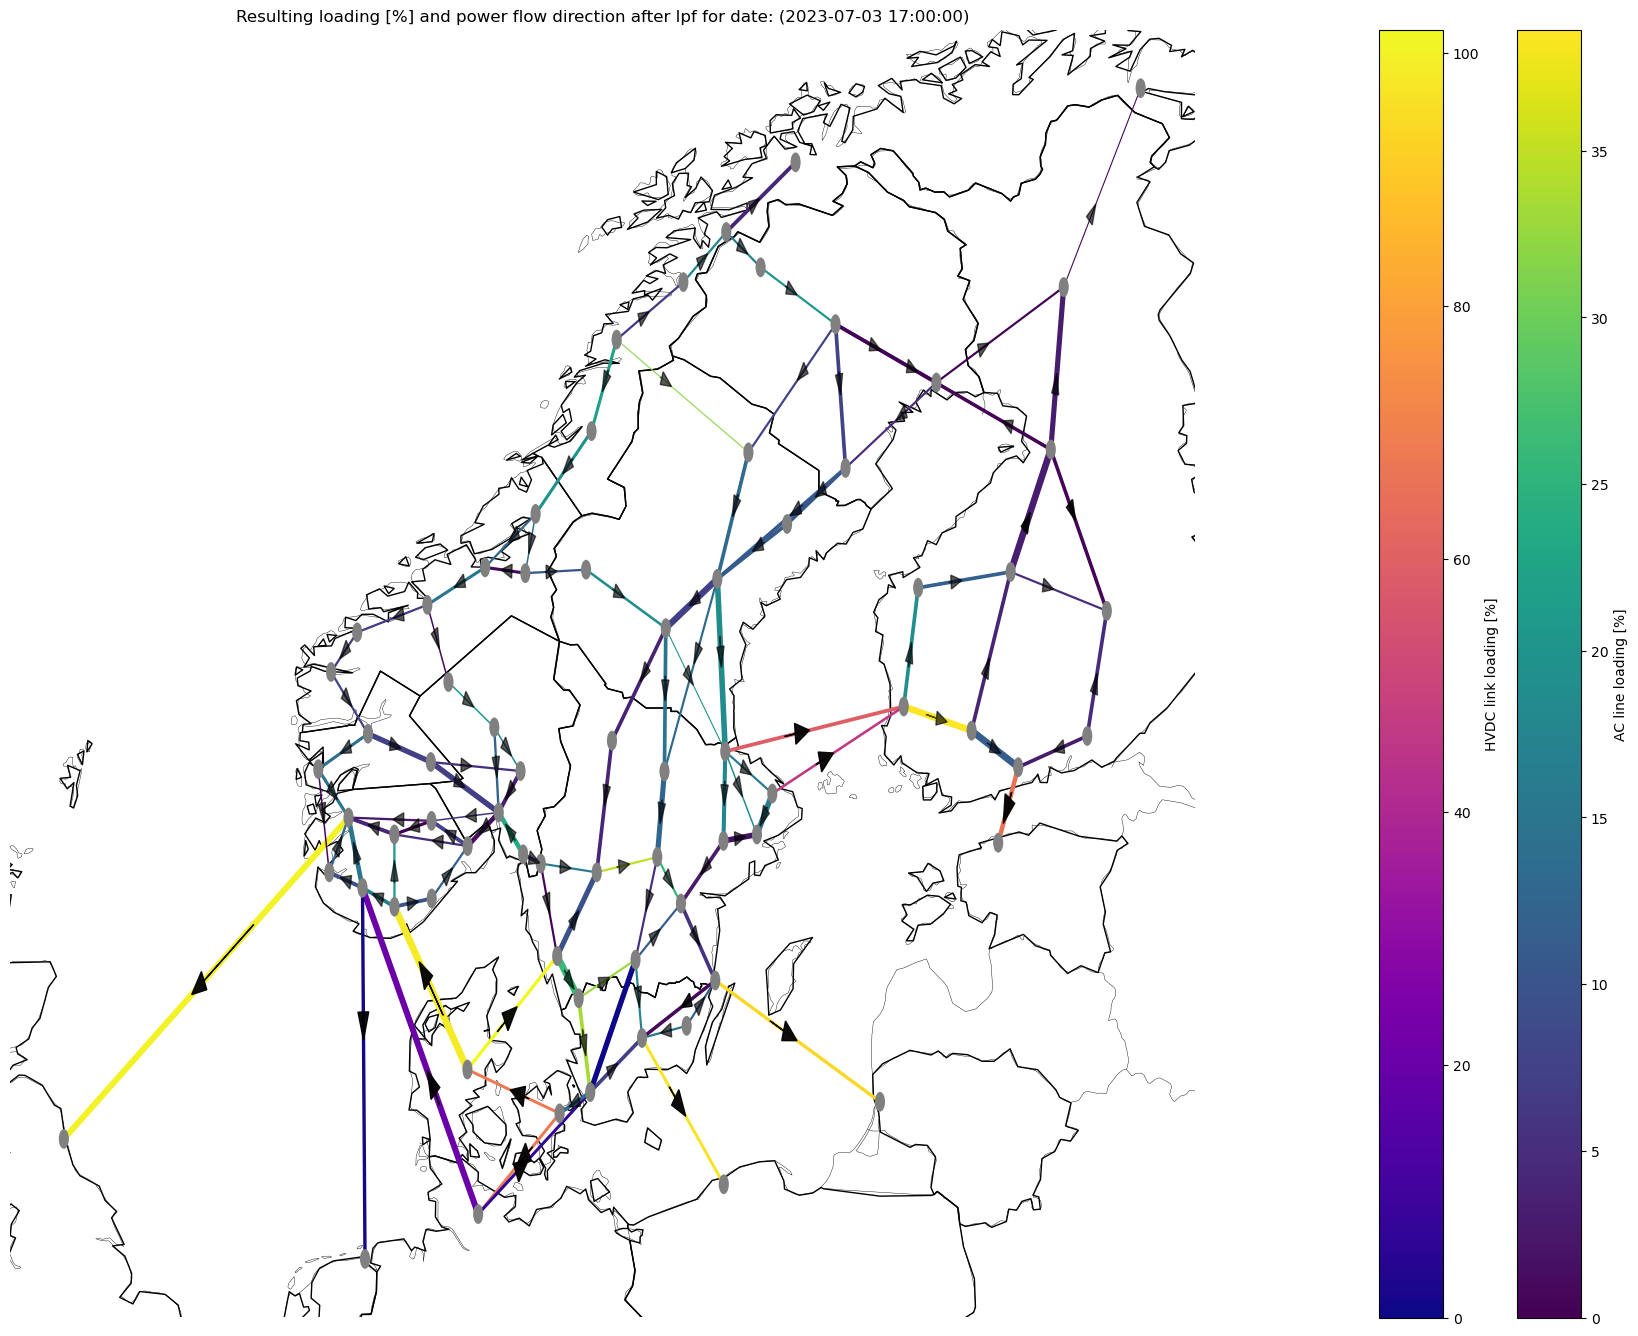

In [19]:
#Specify what max line capacity you want to use for normalization. 1 line in Finland is very capable, and if we don't specify normalization value ourselves, 
#the other lines look really small
plot_network_with_loadings(n, snapshot_number=17, normalization_val_lines=7500) 

Calculating the average error over all cross border flows. In this code we exclude error > 10000 % and cases where p actual < X MW. This is done because low power transfer could be caused by physical reasons, e.g. maintanance and so on.

In [20]:
import pandas as pd

excluded_actual_values = 10  # MW


def compute_crossborder_flows_ac(n, snapshot_index=17):
    """
    Compute net cross-border AC flows (MW) between zones at a given snapshot index.
    Positive = net flow from zone0 → zone1 (direction based on alphabetical order).
    """

    snapshot = n.snapshots[snapshot_index]

    # Map buses to zones
    bus_zones = n.buses["zone"].to_dict()

    # AC lines and their zones
    line_df = n.lines.copy()
    line_df["zone0"] = line_df["bus0"].map(bus_zones)
    line_df["zone1"] = line_df["bus1"].map(bus_zones)

    cross_lines = line_df[line_df["zone0"] != line_df["zone1"]].copy()
    if cross_lines.empty:
        print("No cross-border AC lines found.")
        return pd.DataFrame()

    # Power flow (MW) at snapshot
    p0 = n.lines_t.p0.loc[snapshot, cross_lines.index]
    cross_lines["flow_MW"] = p0

    # Normalize direction alphabetically
    def ordered_flow(row):
        zoneA, zoneB = sorted([row["zone0"], row["zone1"]])
        sign = 1 if (row["zone0"] == zoneA) else -1
        return pd.Series({
            "zoneA": zoneA,
            "zoneB": zoneB,
            "flow_MW": row["flow_MW"] * sign
        })

    ordered = cross_lines.apply(ordered_flow, axis=1)

    flows = (
        ordered.groupby(["zoneA", "zoneB"])["flow_MW"]
        .sum()
        .rename("AC_flow_MW")
        .to_frame()
    )

    return flows.sort_index()



# -------------------------------------------------------------------------
#  DEVIATION CALCULATION ACROSS 24 SNAPSHOTS
# -------------------------------------------------------------------------

all_devs_pct = {}  # percent deviation per border
all_devs_mw = {}   # MW deviation per border
all_model_vals = {}   # store model values to compute average model flow
all_actual_vals = {}  # store actual values to compute average actual flow

for i in range(24):

    # Model flows
    flows_i = compute_crossborder_flows_ac(n, snapshot_index=i)

    flows_dropped = flows_i.reset_index()
    flows_dropped["pair"] = flows_dropped["zoneA"] + "<->" + flows_dropped["zoneB"]
    flows_dropped = flows_dropped.set_index("pair")

    # Actual ENTSO flow
    actual_i = ac_flows_df.iloc[i]

    model_values = {}
    actual_values = {}
    deviations_mw = {}
    deviations_pct = {}

    for pair in flows_dropped.index:

        if pair not in actual_i.index:
            continue

        model_val = flows_dropped.loc[pair, "AC_flow_MW"]
        actual_val = actual_i.loc[pair]

        # Skip invalid or small actual flows
        if pd.isna(actual_val):
            continue
        if abs(actual_val) <= excluded_actual_values or model_val == 0:
            continue

        diff_mw = model_val - actual_val
        diff_pct = (diff_mw / actual_val) * 100

        # avoid insane outliers
        if abs(diff_pct) < 1_000_000:

            deviations_pct[pair] = diff_pct
            deviations_mw[pair] = diff_mw
            model_values[pair] = model_val
            actual_values[pair] = actual_val

            # Save globally
            all_devs_pct.setdefault(pair, []).append(diff_pct)
            all_devs_mw.setdefault(pair, []).append(diff_mw)
            all_model_vals.setdefault(pair, []).append(model_val)
            all_actual_vals.setdefault(pair, []).append(actual_val)

    # snapshot table (not printed here)
    deviation_table = pd.DataFrame({
        "model_MW": model_values,
        "actual_MW": actual_values,
        "MW_diff": deviations_mw,
        "pct_diff": deviations_pct
    })



# -------------------------------------------------------------------------
# 1) Average % deviation per border
# -------------------------------------------------------------------------
avg_pct_per_border = {
    pair: abs(pd.Series(vals)).mean()
    for pair, vals in all_devs_pct.items()
}
avg_pct_series_p = pd.Series(avg_pct_per_border).sort_values()

print("\n=== Average absolute PERCENT deviation per border (24 hours) ===")
print(avg_pct_series_p)


# -------------------------------------------------------------------------
# 2) Average MW deviation per border
# -------------------------------------------------------------------------
avg_mw_per_border = {
    pair: pd.Series(vals).mean()
    for pair, vals in all_devs_mw.items()
}
avg_mw_series = pd.Series(avg_mw_per_border).sort_values()

print("\n=== Average MW deviation per border (model - actual) ===")
print(avg_mw_series)


# -------------------------------------------------------------------------
# 3) Global overall percent deviation
# -------------------------------------------------------------------------
all_pct_values = [v for vals in all_devs_pct.values() for v in vals]
global_avg_pct_p = abs(pd.Series(all_pct_values)).mean()

print("\n=== Global average percent deviation across all borders & snapshots ===")
print(f"{global_avg_pct_p:.2f}%")


# -------------------------------------------------------------------------
# 4) Average MODEL and ACTUAL flow per border (NEW)
# -------------------------------------------------------------------------
avg_model_flow = {pair: pd.Series(vals).mean() for pair, vals in all_model_vals.items()}
avg_actual_flow = {pair: pd.Series(vals).mean() for pair, vals in all_actual_vals.items()}

avg_model_flow_series = pd.Series(avg_model_flow)
avg_actual_flow_series = pd.Series(avg_actual_flow)

print("\n=== Average MODEL flow per border (MW) ===")
print(avg_model_flow_series.sort_values())

print("\n=== Average ACTUAL flow per border (MW) ===")
print(avg_actual_flow_series.sort_values())


# -------------------------------------------------------------------------
# 5) Combine everything into ONE final table
# -------------------------------------------------------------------------
final_table = pd.DataFrame({
    "avg_pct_deviation": avg_pct_series_p,
    "avg_MW_deviation": avg_mw_series,
    "avg_model_flow_MW": avg_model_flow_series,
    "avg_actual_flow_MW": avg_actual_flow_series
})

print("\n=== FINAL SUMMARY TABLE ===")
print(final_table.sort_index())



=== Average absolute PERCENT deviation per border (24 hours) ===
DK_2<->SE_4     19.378662
NO_3<->NO_4     31.168417
NO_4<->SE_2     31.396180
SE_2<->SE_3     41.247474
NO_4<->SE_1     71.652957
SE_3<->SE_4     74.537604
SE_1<->SE_2     75.231395
FI<->SE_1       81.437583
NO_3<->SE_2     97.198125
NO_2<->NO_5    104.768224
FI<->NO_4      119.271484
NO_1<->NO_2    133.023162
NO_1<->NO_3    144.298817
NO_1<->SE_3    178.453808
NO_1<->NO_5    231.390714
NO_3<->NO_5    308.889325
dtype: float64

=== Average MW deviation per border (model - actual) ===
SE_2<->SE_3   -735.142090
NO_1<->NO_2   -664.392085
SE_3<->SE_4   -416.261875
SE_1<->SE_2   -349.096712
NO_1<->NO_5   -275.694753
NO_3<->SE_2   -256.872279
FI<->SE_1     -250.697555
NO_2<->NO_5   -224.950741
NO_4<->SE_1    -66.531645
NO_4<->SE_2      0.207092
DK_2<->SE_4     10.630208
FI<->NO_4       31.323324
NO_3<->NO_5    117.258313
NO_3<->NO_4    152.158210
NO_1<->NO_3    172.466622
NO_1<->SE_3    744.347819
dtype: float64

=== Global av

In [21]:
#excluded_actual_values = 0  # MW. Already defined above

def compute_crossborder_flows_ac(n, snapshot_index=17):
    """
    Compute net cross-border AC flows (MW) between zones at a given snapshot index.
    Positive = net flow from zone0 → zone1 (direction based on alphabetical order of zones).
    """

    # Select snapshot
    snapshot = n.snapshots[snapshot_index]

    # Map buses to zones
    bus_zones = n.buses["zone"].to_dict()

    # AC lines that connect different zones
    line_df = n.lines.copy()
    line_df["zone0"] = line_df["bus0"].map(bus_zones)
    line_df["zone1"] = line_df["bus1"].map(bus_zones)

    cross_lines = line_df[line_df["zone0"] != line_df["zone1"]].copy()
    if cross_lines.empty:
        print("No cross-border AC lines found.")
        return pd.DataFrame()

    # Power flow (MW)
    p0 = n.lines_t.p0.loc[snapshot, cross_lines.index]
    cross_lines["flow_MW"] = p0

    # Define directed pairs based on alphabetical order
    def ordered_flow(row):
        zoneA, zoneB = sorted([row["zone0"], row["zone1"]])
        sign = 1 if (row["zone0"] == zoneA) else -1
        return pd.Series({
            "zoneA": zoneA,
            "zoneB": zoneB,
            "flow_MW": row["flow_MW"] * sign
        })

    ordered = cross_lines.apply(ordered_flow, axis=1)

    # Sum lines between zone pairs
    flows = (
        ordered.groupby(["zoneA", "zoneB"])["flow_MW"]
        .sum()
        .rename("AC_flow_MW")
        .to_frame()
    )

    return flows.sort_index()



# ================================
#     Run SMAPE deviation calc
# ================================

all_devs_pct = {}   # normalized SMAPE (%) deviation
all_devs_mw  = {}   # MW deviation

for i in range(24):
    #print(f"\n=== Snapshot {i} ===")

    # Compute model flows
    flows_i = compute_crossborder_flows_ac(n, snapshot_index=i)

    flows_dropped = flows_i.reset_index()
    flows_dropped["pair"] = flows_dropped["zoneA"] + "<->" + flows_dropped["zoneB"]
    flows_dropped = flows_dropped.set_index("pair")

    # Actual ENTSO flow
    actual_i = ac_flows_df.iloc[i]

    # Per-snapshot temporary storage
    deviations_pct = {}
    deviations_mw = {}
    model_values = {}
    actual_values = {}

    for pair in flows_dropped.index:

        if pair not in actual_i.index:
            continue

        model_val = flows_dropped.loc[pair, "AC_flow_MW"]
        actual_val = actual_i.loc[pair]

        if pd.isna(actual_val):
            continue

        # Skip small actual flows (unstable percent metrics)
        if (abs(actual_val) <= excluded_actual_values) or (model_val == 0):
            continue

        # MW deviation
        diff_mw = model_val - actual_val

        # ================================
        #   SMAPE-normalized deviation
        # ================================
        smape = abs(diff_mw) / ((abs(model_val) + abs(actual_val)) / 2) * 100
        # Value is in percent-like scale (0–200%)

        # Filter extreme values (optional, still allowed)
        if smape < 1000000:
            deviations_pct[pair] = smape
            deviations_mw[pair] = diff_mw
            model_values[pair] = model_val
            actual_values[pair] = actual_val

            # Save globally
            all_devs_pct.setdefault(pair, []).append(smape)
            all_devs_mw.setdefault(pair, []).append(diff_mw)


    # Build snapshot deviation table
    deviation_table = pd.DataFrame({
        "model_MW": model_values,
        "actual_MW": actual_values,
        "MW_diff": deviations_mw,
        "SMAPE_pct": deviations_pct
    })

    #print(deviation_table)



# ================================
#      Aggregated Statistics
# ================================

# 1. Average normalized deviation per border
avg_pct_per_border = {
    pair: abs(pd.Series(vals)).mean()
    for pair, vals in all_devs_pct.items()
}
avg_pct_series_s = pd.Series(avg_pct_per_border).sort_values()

print("\n=== Average SMAPE deviation per border (%) over 24 hours ===")
print(avg_pct_series_s)


# 2. Average MW deviation per border
avg_mw_per_border = {
    pair: pd.Series(vals).mean()
    for pair, vals in all_devs_mw.items()
}
avg_mw_series = pd.Series(avg_mw_per_border).sort_values()

print("\n=== Average MW deviation per border (model - actual) ===")
print(avg_mw_series)


# 3. Global average normalized deviation
all_pct_values = [v for vals in all_devs_pct.values() for v in vals]
global_avg_pct_s = abs(pd.Series(all_pct_values)).mean()

print("\n=== Global average SMAPE deviation across all borders & snapshots ===")
print(f"{global_avg_pct_s:.2f}%")






=== Average SMAPE deviation per border (%) over 24 hours ===
DK_2<->SE_4     17.893446
NO_3<->NO_4     35.886427
NO_4<->SE_2     39.111342
SE_3<->SE_4     52.293146
SE_2<->SE_3     52.943650
NO_4<->SE_1     63.570232
NO_2<->NO_5     65.223426
FI<->SE_1       71.425257
SE_1<->SE_2     91.321002
NO_3<->SE_2    101.871385
NO_1<->NO_5    115.105551
NO_1<->SE_3    136.526367
NO_1<->NO_2    138.501610
FI<->NO_4      154.856155
NO_1<->NO_3    160.167244
NO_3<->NO_5    167.892864
dtype: float64

=== Average MW deviation per border (model - actual) ===
SE_2<->SE_3   -735.142090
NO_1<->NO_2   -664.392085
SE_3<->SE_4   -416.261875
SE_1<->SE_2   -349.096712
NO_1<->NO_5   -275.694753
NO_3<->SE_2   -256.872279
FI<->SE_1     -250.697555
NO_2<->NO_5   -224.950741
NO_4<->SE_1    -66.531645
NO_4<->SE_2      0.207092
DK_2<->SE_4     10.630208
FI<->NO_4       31.323324
NO_3<->NO_5    117.258313
NO_3<->NO_4    152.158210
NO_1<->NO_3    172.466622
NO_1<->SE_3    744.347819
dtype: float64

=== Global averag

In [22]:
from collections import defaultdict
import pandas as pd

#excluded_actual_values = 0  # MW


def compute_crossborder_flows_ac(n, snapshot_index=17):
    """
    Compute net cross-border AC flows (MW) between zones at a given snapshot index.
    Positive = net flow from zone0 → zone1 (direction based on alphabetical order of zones).
    """

    snapshot = n.snapshots[snapshot_index]

    # Map buses to zones
    bus_zones = n.buses["zone"].to_dict()

    # AC lines that connect different zones
    line_df = n.lines.copy()
    line_df["zone0"] = line_df["bus0"].map(bus_zones)
    line_df["zone1"] = line_df["bus1"].map(bus_zones)
    cross_lines = line_df[line_df["zone0"] != line_df["zone1"]].copy()

    if cross_lines.empty:
        print("No cross-border AC lines found.")
        return pd.DataFrame()

    # Power flow (MW)
    p0 = n.lines_t.p0.loc[snapshot, cross_lines.index]
    cross_lines["flow_MW"] = p0

    # Normalize direction based on alphabetical zone order
    def ordered_flow(row):
        zoneA, zoneB = sorted([row["zone0"], row["zone1"]])
        sign = 1 if row["zone0"] == zoneA else -1
        return pd.Series({
            "zoneA": zoneA,
            "zoneB": zoneB,
            "flow_MW": row["flow_MW"] * sign
        })

    ordered = cross_lines.apply(ordered_flow, axis=1)

    # Sum parallel lines
    flows = (
        ordered.groupby(["zoneA", "zoneB"])["flow_MW"]
        .sum()
        .rename("AC_flow_MW")
        .to_frame()
    )

    return flows.sort_index()



# ============================================================
#        ACCUMULATORS FOR POWER-WEIGHTED ERROR (WAPE)
# ============================================================

border_abs_err_sum = defaultdict(float)   # Σ |model - actual|
border_abs_act_sum = defaultdict(float)   # Σ |actual|
global_abs_err_sum = 0.0
global_abs_act_sum = 0.0


# Store raw deviations for inspection (optional)
all_devs_pct = {}
all_devs_mw = {}

# ============================================================
#                     SNAPSHOT LOOP
# ============================================================

for i in range(24):
    #print(f"\n=== Snapshot {i} ===")

    flows_i = compute_crossborder_flows_ac(n, snapshot_index=i)

    flows_dropped = flows_i.reset_index()
    flows_dropped["pair"] = flows_dropped["zoneA"] + "<->" + flows_dropped["zoneB"]
    flows_dropped = flows_dropped.set_index("pair")

    actual_i = ac_flows_df.iloc[i]

    deviations_pct = {}
    deviations_mw = {}
    model_values = {}
    actual_values = {}

    for pair in flows_dropped.index:

        if pair not in actual_i.index:
            continue

        model_val = flows_dropped.loc[pair, "AC_flow_MW"]
        actual_val = actual_i.loc[pair]

        # Skip bad values
        if pd.isna(actual_val):
            continue
        if abs(actual_val) <= excluded_actual_values:
            continue

        # MW deviation
        diff_mw = model_val - actual_val

        # Percent (for inspection only)
        pct_diff = (diff_mw / actual_val) * 100

        # Store snapshot-level values
        deviations_pct[pair] = pct_diff
        deviations_mw[pair] = diff_mw
        model_values[pair] = model_val
        actual_values[pair] = actual_val

        # Accumulate weighted errors
        abs_err = abs(diff_mw)
        abs_act = abs(actual_val)

        border_abs_err_sum[pair] += abs_err
        border_abs_act_sum[pair] += abs_act

        global_abs_err_sum += abs_err
        global_abs_act_sum += abs_act

        # Optional: keep raw lists
        all_devs_pct.setdefault(pair, []).append(pct_diff)
        all_devs_mw.setdefault(pair, []).append(diff_mw)

    # Print snapshot results
    deviation_table = pd.DataFrame({
        "model_MW": model_values,
        "actual_MW": actual_values,
        "MW_diff": deviations_mw,
        "pct_diff": deviations_pct
    })

    #print(deviation_table)


# ============================================================
#          POWER-WEIGHTED ERROR (WAPE) RESULTS
# ============================================================

# Per-border WAPE (weighted absolute percentage error)
wape_per_border = {
    pair: 100 * border_abs_err_sum[pair] / border_abs_act_sum[pair]
    for pair in border_abs_err_sum.keys()
    if border_abs_act_sum[pair] > 0
}

wape_series = pd.Series(wape_per_border).sort_values()

print("\n=== Power-weighted error PER BORDER (Σ|diff| / Σ|actual| * 100) ===")
print(wape_series)

# Global WAPE across all borders and snapshots
global_wape_pct = 100 * global_abs_err_sum / global_abs_act_sum

print("\n=== GLOBAL power-weighted error across all borders & snapshots ===")
print(f"{global_wape_pct:.2f}%")



=== Power-weighted error PER BORDER (Σ|diff| / Σ|actual| * 100) ===
DK_2<->SE_4      2.821098
NO_4<->SE_2     23.305827
SE_3<->SE_4     26.894276
NO_3<->NO_4     29.733705
SE_2<->SE_3     32.459339
NO_4<->SE_1     43.471323
SE_1<->SE_2     49.449607
FI<->SE_1       49.744539
NO_1<->NO_2     67.384956
NO_3<->SE_2     67.862367
NO_2<->NO_5     81.992319
NO_1<->SE_3     88.485813
NO_1<->NO_3     99.467207
FI<->NO_4      110.820182
NO_1<->NO_5    119.310580
NO_3<->NO_5    286.054021
dtype: float64

=== GLOBAL power-weighted error across all borders & snapshots ===
49.09%


In [23]:
# Convert series to DataFrames
avg_error_rel_df = avg_pct_series_p.to_frame(name="pct_error")   # percent deviation
smape_df         = avg_pct_series_s.to_frame(name="smape_error") # smape deviation
wape_df          = wape_series.to_frame(name="wape_error")       # wape error
MW_diff_df       = avg_mw_series.to_frame(name="MW deviation")
MW_actual_df     = avg_actual_flow_series.to_frame(name="Actual MW")
MW_model_df      = avg_model_flow_series.to_frame(name="Model MW")
# Combine all three (align on zone-pair index)
combined_df = avg_error_rel_df.join([smape_df, wape_df, MW_actual_df, MW_model_df, MW_diff_df], how="outer")


combined_df.loc["Entire Nordic area"] = {
    "pct_error": global_avg_pct_p,
    "smape_error": global_avg_pct_s,
    "wape_error": global_wape_pct,

}

#combined_df.loc["TOTAL_SUM_ROW"] = combined_df.sum(numeric_only=True)


print("\n=== Combined percent errors ===")
print(combined_df)



=== Combined percent errors ===
                     pct_error  smape_error  wape_error    Actual MW  \
DK_2<->SE_4          19.378662    17.893446    2.821098  -237.935417   
NO_3<->NO_4          31.168417    35.886427   29.733705  -593.290000   
NO_4<->SE_2          31.396180    39.111342   23.305827    98.415000   
SE_2<->SE_3          41.247474    52.943650   32.459339  2264.809167   
NO_4<->SE_1          71.652957    63.570232   43.471323   289.600417   
SE_3<->SE_4          74.537604    52.293146   26.894276  1401.339167   
SE_1<->SE_2          75.231395    91.321002   49.449607   515.150417   
FI<->SE_1            81.437583    71.425257   49.744539  -274.988261   
NO_3<->SE_2          97.198125   101.871385   67.862367   205.755833   
NO_2<->NO_5         104.768224    65.223426   81.992319  -268.340000   
FI<->NO_4           119.271484   154.856155  110.820182   -28.265000   
NO_1<->NO_2         133.023162   138.501610   67.384956   979.270833   
NO_1<->NO_3         144.298817 

In [24]:

excluded_actual_values = 500  # MW

def compute_crossborder_flows_ac_2(n, snapshot_index=17):
    """
    Compute net cross-border AC flows (MW) between zones at a given snapshot index.
    Positive = net flow from alphabetically lower zone → higher zone.
    Includes list of contributing line IDs for each zone pair.
    """

    # Select snapshot
    snapshot = n.snapshots[snapshot_index]

    #  Map buses to zones 
    bus_zones = n.buses["zone"].to_dict()

    #  Identify AC lines crossing different zones 
    line_df = n.lines.copy()
    line_df["zone0"] = line_df["bus0"].map(bus_zones)
    line_df["zone1"] = line_df["bus1"].map(bus_zones)

    cross_lines = line_df[line_df["zone0"] != line_df["zone1"]].copy()
    if cross_lines.empty:
        print("No cross-border AC lines found.")
        return pd.DataFrame()

    #  Power flow (MW) for selected snapshot 
    p0 = n.lines_t.p0.loc[snapshot, cross_lines.index]
    cross_lines["flow_MW"] = p0

    #  Normalize direction by alphabetical order of zones 
    def ordered_flow(row):
        zoneA, zoneB = sorted([row["zone0"], row["zone1"]])
        sign = 1 if row["zone0"] == zoneA else -1
        return pd.Series({
            "zoneA": zoneA,
            "zoneB": zoneB,
            "flow_MW": row["flow_MW"] * sign,
            "line_name": row.name
        })

    ordered = cross_lines.apply(ordered_flow, axis=1)

    #  Group by zone pair: sum flow and collect line names 
    flows = (
        ordered.groupby(["zoneA", "zoneB"])
        .agg(
            AC_flow_MW=("flow_MW", "sum"),
            lines_included=("line_name", lambda x: ", ".join(x))
        )
        .reset_index()
        .sort_values(["zoneA", "zoneB"])
        .set_index(["zoneA", "zoneB"])
    )

    return flows

# Track total and correct directions
total_count = 0
correct_count = 0

# Store per-snapshot accuracy (optional)
sign_accuracy = []

for i in range(24):  # assuming 24 snapshots

    # Modelled flows
    model_flows = compute_crossborder_flows_ac_2(n, snapshot_index=i)
    model_df = model_flows.reset_index()
    model_df["pair"] = model_df["zoneA"] + "<->" + model_df["zoneB"]
    model_df = model_df.set_index("pair")

    # Actual measured flows
    actual = ac_flows_df.iloc[i]

    # Align model and actual zone pairs 
    common_pairs = model_df.index.intersection(actual.index)
    if common_pairs.empty:
        continue

    model_vals = model_df.loc[common_pairs, "AC_flow_MW"]
    actual_vals = actual.loc[common_pairs]

    # Exclude small actual flows (< X MW)
    valid_mask = actual_vals.abs() >= excluded_actual_values

    if valid_mask.sum() == 0:
        print(f"\nSnapshot {i:02d}: No valid flows (all <50 MW). Skipping.")
        continue

    model_vals = model_vals[valid_mask]
    actual_vals = actual_vals[valid_mask]
    filtered_pairs = model_vals.index

    #  Compare signs only on filtered pairs 
    sign_match = np.sign(model_vals) == np.sign(actual_vals)
    correct = sign_match.sum()
    total = len(sign_match)

    #  Identify incorrect sign pairs 
    wrong_pairs = filtered_pairs[~sign_match]

    print(f"\nSnapshot {i:02d}: {correct}/{total} ({correct/total*100:.1f}%) correct directions")

    if len(wrong_pairs) > 0:
        print("  Incorrect direction for:")
        for pair in wrong_pairs:
            mval = model_vals.loc[pair]
            aval = actual_vals.loc[pair]
            print(f"    {pair}: model={mval:.2f} MW, actual={aval:.2f} MW")
    else:
        print("  All flow directions correct.")

    #  Track results 
    correct_count += correct
    total_count += total
    sign_accuracy.append(correct / total * 100)

#  Overall accuracy 
overall_accuracy = correct_count / total_count * 100

print("\n=== Directional accuracy summary ===")
print(f"Total matches: {correct_count}/{total_count}")
print(f"Overall accuracy: {overall_accuracy:.1f}%")
print(f"Average per-snapshot accuracy: {np.mean(sign_accuracy):.1f}%")



Snapshot 00: 6/6 (100.0%) correct directions
  All flow directions correct.

Snapshot 01: 5/5 (100.0%) correct directions
  All flow directions correct.

Snapshot 02: 5/5 (100.0%) correct directions
  All flow directions correct.

Snapshot 03: 7/7 (100.0%) correct directions
  All flow directions correct.

Snapshot 04: 6/6 (100.0%) correct directions
  All flow directions correct.

Snapshot 05: 4/4 (100.0%) correct directions
  All flow directions correct.

Snapshot 06: 6/6 (100.0%) correct directions
  All flow directions correct.

Snapshot 07: 7/8 (87.5%) correct directions
  Incorrect direction for:
    NO_1<->SE_3: model=59.98 MW, actual=-901.78 MW

Snapshot 08: 8/8 (100.0%) correct directions
  All flow directions correct.

Snapshot 09: 5/6 (83.3%) correct directions
  Incorrect direction for:
    NO_1<->SE_3: model=104.59 MW, actual=-651.80 MW

Snapshot 10: 5/5 (100.0%) correct directions
  All flow directions correct.

Snapshot 11: 4/4 (100.0%) correct directions
  All flow dir

In [25]:

mask = ac_flows_df.abs() <= excluded_actual_values
print(f"Number of values with |value| < {excluded_actual_values}:", mask.sum().sum())

small_values = ac_flows_df[mask]

# Convert to a stacked format for readable output
small_entries = small_values[mask].stack()

print(f"\n All values where |value| < {excluded_actual_values} MW ")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(small_entries)



Number of values with |value| < 500: 242

 All values where |value| < 500 MW 
Snapshot                        
2023-07-03 00:00:00  DK_2<->SE_4    -36.7500
                     FI<->NO_4      -12.1125
                     FI<->SE_1      280.1500
                     NO_1<->NO_3   -315.5000
                     NO_1<->NO_5    120.0200
                     NO_2<->NO_5   -344.5600
                     NO_3<->NO_5    -76.6600
                     NO_3<->SE_2    115.6800
                     NO_4<->SE_1    266.1400
                     NO_4<->SE_2     88.1700
2023-07-03 01:00:00  DK_2<->SE_4     35.8200
                     FI<->NO_4       -3.9900
                     FI<->SE_1      292.9100
                     NO_1<->NO_3   -244.0500
                     NO_1<->NO_5    133.5800
                     NO_2<->NO_5   -289.3600
                     NO_3<->NO_4   -458.8500
                     NO_3<->NO_5    -76.3500
                     NO_3<->SE_2    -57.6000
                     NO_4<->SE_1  

In [26]:
# Group by bus + carrier and sum installed nominal power
capacity_by_bus_and_carrier = (
    n.generators
    .groupby(["bus", "carrier"])["p_nom"]
    .sum()
    .unstack(fill_value=0)
)
#print(capacity_by_bus_and_carrier)

In [27]:
# Ensure generators have zone mapped
n.generators["zone"] = n.generators["bus"].map(n.buses["zone"])
zone = "SE_3"

# Filter generators in that zone
gens_in_zone = n.generators[n.generators["zone"] == zone]

# Group by carrier → sum timeseries for each carrier separately
production_by_carrier = (
    n.generators_t.p[gens_in_zone.index]
    .groupby(gens_in_zone["carrier"], axis=1)
    .sum()
)

#print(production_by_carrier)

C:\Users\aleks\AppData\Local\Temp\ipykernel_34532\490442407.py:11: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



Finding production for the slack generators. Just to see that something actually happens. 

In [28]:
# 1️⃣ Find buses without zone
buses_without_zone = n.buses[n.buses["zone"].isna() | (n.buses["zone"] == "")]
bus_list = buses_without_zone.index.tolist()

print(f"=== Buses without zone ({len(bus_list)}) ===")
print(bus_list)

# 2️⃣ Find generators connected to those buses
gens_without_zone = n.generators[n.generators["bus"].isin(bus_list)]

print(f"\n=== Generators connected to unzoned buses ({len(gens_without_zone)}) ===")
if gens_without_zone.empty:
    print("✅ No generators connected to unzoned buses.")
else:
    print(gens_without_zone[["bus", "carrier", "p_nom"]])

    # 3️⃣ Show their production time series
    # Choose either p (actual dispatch) or p_set (setpoint / target)
    gen_names = gens_without_zone.index
    production_ts = n.generators_t.p.loc[:, gen_names]

    print("\n=== Production of generators connected to unzoned buses ===")
    print(production_ts.head(24))  # first 24 hours (or snapshots)



slack_gens = n.generators[n.generators["carrier"] == "slack"]
p_slack = n.generators_t.p[slack_gens.index]
slack_prod_per_zone = p_slack.groupby(slack_gens["zone"], axis=1).sum()

print(slack_prod_per_zone.head(100))

n.generators.columns

=== Buses without zone (6) ===
['DE', 'NL', 'GB', 'PL', 'LT', 'EE']

=== Generators connected to unzoned buses (6) ===


          bus carrier  p_nom
Generator                   
slack_DE   DE   slack    0.0
slack_NL   NL   slack    0.0
slack_GB   GB   slack    0.0
slack_PL   PL   slack    0.0
slack_LT   LT   slack    0.0
slack_EE   EE   slack    0.0

=== Production of generators connected to unzoned buses ===
Generator             slack_DE  slack_NL  slack_GB  slack_PL  slack_LT  \
snapshot                                                                 
2023-07-03 00:00:00 -1870.4975 -622.1850  -1379.68    -434.5   -270.38   
2023-07-03 01:00:00 -1814.3550 -601.5000   -968.35    -413.0   -189.14   
2023-07-03 02:00:00 -1870.9950 -528.8925   -937.32    -303.1    -97.11   
2023-07-03 03:00:00 -1881.6175 -277.4525   -510.43    -297.5     10.67   
2023-07-03 04:00:00 -1880.9475 -327.0975   -206.98    -297.5   -194.45   
2023-07-03 05:00:00 -1846.7975 -612.2125   -509.15    -297.4   -516.41   
2023-07-03 06:00:00 -1837.5175 -622.7275   -953.92    -297.5   -663.60   
2023-07-03 07:00:00 -1726.9225 -602.7675 

C:\Users\aleks\AppData\Local\Temp\ipykernel_34532\1651945678.py:29: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



Index(['bus', 'control', 'type', 'p_nom', 'p_nom_mod', 'p_nom_extendable',
       'p_nom_min', 'p_nom_max', 'p_min_pu', 'p_max_pu', 'p_set', 'e_sum_min',
       'e_sum_max', 'q_set', 'sign', 'carrier', 'marginal_cost',
       'marginal_cost_quadratic', 'active', 'build_year', 'lifetime',
       'capital_cost', 'efficiency', 'committable', 'start_up_cost',
       'shut_down_cost', 'stand_by_cost', 'min_up_time', 'min_down_time',
       'up_time_before', 'down_time_before', 'ramp_limit_up',
       'ramp_limit_down', 'ramp_limit_start_up', 'ramp_limit_shut_down',
       'weight', 'p_nom_opt', 'zone', 'production_share'],
      dtype='object')

Testing cells below. For results. Power flow results sometimes differ wildly from the expected ones. Look at this together. 

In [29]:
import pandas as pd
import numpy as np

def compute_crossborder_flows_ac(n, snapshot_index=17):
    """
    Compute net cross-border AC flows (MW) between zones at a given snapshot index.
    Positive = net flow from zone0 → zone1 (direction based on alphabetical order of zones).
    """

    #Select snapshot
    snapshot = n.snapshots[snapshot_index]

    #Map buses to zones
    bus_zones = n.buses["zone"].to_dict()

    #AC lines that connect different zones
    line_df = n.lines.copy()
    line_df["zone0"] = line_df["bus0"].map(bus_zones)
    line_df["zone1"] = line_df["bus1"].map(bus_zones)

    cross_lines = line_df[line_df["zone0"] != line_df["zone1"]].copy()
    if cross_lines.empty:
        print("No cross-border AC lines found.")
        return pd.DataFrame()

    #  Power flow (MW) for selected snapshot 
    p0 = n.lines_t.p0.loc[snapshot, cross_lines.index]
    cross_lines["flow_MW"] = p0

    #  Define *directed* pairs based on alphabetical order 
    def ordered_flow(row):
        # Always order zones alphabetically to keep one direction per pair
        zoneA, zoneB = sorted([row["zone0"], row["zone1"]])
        # If the alphabetical order reverses original direction, invert sign
        sign = 1 if (row["zone0"] == zoneA) else -1
        return pd.Series({"zoneA": zoneA, "zoneB": zoneB, "flow_MW": row["flow_MW"] * sign})

    ordered = cross_lines.apply(ordered_flow, axis=1)

    #  Sum up all lines between each zone pair 
    flows = (
        ordered.groupby(["zoneA", "zoneB"])["flow_MW"]
        .sum()
        .rename("AC_flow_MW")
        .to_frame()
    )

    #  Sort for readability 
    return flows.sort_index()



In [30]:
index_no = 0

flows = compute_crossborder_flows_ac(n, snapshot_index=index_no)

# Drop rows by integer position (row 1 and 2)
flows_dropped = flows.reset_index() #dropping rows because we dont have data for this from entsoe
#flows_dropped = flows.reset_index()
print("\n=== Cross-border flows (MW) ===")
print(flows_dropped)
#flows_dropped.iloc[0,2]

total_trans_model = flows_dropped['AC_flow_MW'].abs().sum()
print(total_trans_model)


test = ac_flows_df.iloc[index_no]
print(test)

total_trans_actual = test.abs().sum(axis=0)
print(total_trans_actual)


=== Cross-border flows (MW) ===
   zoneA zoneB   AC_flow_MW
0   DK_2  SE_4   -29.417500
1     FI  NO_4    13.760372
2     FI  SE_1    31.674628
3   NO_1  NO_2  1366.001459
4   NO_1  NO_3  -109.599055
5   NO_1  NO_5  -137.119280
6   NO_1  SE_3 -1039.603124
7   NO_2  NO_5  -874.713541
8   NO_3  NO_4  -550.693949
9   NO_3  NO_5   338.582821
10  NO_3  SE_2  -253.357926
11  NO_4  SE_1   140.150084
12  NO_4  SE_2    65.386339
13  SE_1  SE_2   222.414711
14  SE_2  SE_3  1611.283124
15  SE_3  SE_4  1022.807500
7806.565414457948
DK_2<->SE_4     -36.7500
FI<->NO_4       -12.1125
FI<->SE_1       280.1500
NO_1<->NO_2    2334.7700
NO_1<->NO_3    -315.5000
NO_1<->NO_5     120.0200
NO_1<->SE_3   -1946.7800
NO_2<->NO_5    -344.5600
NO_3<->NO_4    -587.8300
NO_3<->NO_5     -76.6600
NO_3<->SE_2     115.6800
NO_4<->SE_1     266.1400
NO_4<->SE_2      88.1700
SE_1<->SE_2     644.8500
SE_2<->SE_3    2567.8900
SE_3<->SE_4    1190.5400
Name: 2023-07-03 00:00:00, dtype: float64
10928.4025


In [31]:
model_totals = []
actual_totals = []

for index_no in range(24):

    # --- MODEL TOTAL ---
    flows = compute_crossborder_flows_ac(n, snapshot_index=index_no)
    flows_dropped = flows.reset_index()
    total_trans_model = flows_dropped['AC_flow_MW'].abs().sum()
    model_totals.append(total_trans_model)

    # --- ACTUAL TOTAL ---
    test = ac_flows_df.iloc[index_no]
    total_trans_actual = test.abs().sum()
    actual_totals.append(total_trans_actual)

# --- AVERAGE TOTALS ---
avg_model_total = sum(model_totals) / len(model_totals)
avg_actual_total = sum(actual_totals) / len(actual_totals)

print("Model totals:", model_totals)
print("Actual totals:", actual_totals)
print("\nAverage model total:", avg_model_total)
print("Average actual total:", avg_actual_total)

diff = np.array(model_totals) - np.array(actual_totals)
print(diff)


Model totals: [7806.565414457948, 6998.044302593025, 6696.26227288454, 6876.9864607283, 6511.748236389928, 5686.035544888289, 8126.421672275448, 9302.65672548788, 9937.744176980701, 4833.879247536238, 4352.061530677352, 4788.339407821899, 5881.789849412109, 3825.280465839607, 5080.713817564977, 3855.901610399117, 3168.418893790097, 7733.6688584981775, 10611.184901969362, 11197.203607162119, 12115.09037105654, 12361.648764989452, 12627.47568679498, 12468.783789240902]
Actual totals: [10928.4025, 9669.6, 9541.46, 9355.960000000001, 9126.0275, 8308.2375, 11254.23, 12697.369999999999, 12122.1975, 7286.8525, 5760.200000000001, 4904.014999999999, 5630.7425, 4060.0649999999996, 5362.772500000001, 3428.82, 5514.135, 10998.115, 12961.97, 13116.5875, 13363.970000000001, 13891.6025, 14213.757500000002, 13468.737500000001]

Average model total: 7618.4960670599585
Average actual total: 9456.909479166667
[-3121.83708554 -2671.55569741 -2845.19772712 -2478.97353927
 -2614.27926361 -2622.20195511 -312

Code below calculates the cross border flow, and shows which lines are crossing 

In [32]:
def compute_crossborder_flows_ac_2(n, snapshot_index=17):
    """
    Compute net cross-border AC flows (MW) between zones at a given snapshot index.
    Positive = net flow from alphabetically lower zone → higher zone.
    Includes list of contributing line IDs for each zone pair.
    """

    # Select snapshot
    snapshot = n.snapshots[snapshot_index]

    #  Map buses to zones 
    bus_zones = n.buses["zone"].to_dict()

    #  Identify AC lines crossing different zones 
    line_df = n.lines.copy()
    line_df["zone0"] = line_df["bus0"].map(bus_zones)
    line_df["zone1"] = line_df["bus1"].map(bus_zones)

    cross_lines = line_df[line_df["zone0"] != line_df["zone1"]].copy()
    if cross_lines.empty:
        print("No cross-border AC lines found.")
        return pd.DataFrame()

    #  Power flow (MW) for selected snapshot 
    p0 = n.lines_t.p0.loc[snapshot, cross_lines.index]
    cross_lines["flow_MW"] = p0

    #  Normalize direction by alphabetical order of zones 
    def ordered_flow(row):
        zoneA, zoneB = sorted([row["zone0"], row["zone1"]])
        sign = 1 if row["zone0"] == zoneA else -1
        return pd.Series({
            "zoneA": zoneA,
            "zoneB": zoneB,
            "flow_MW": row["flow_MW"] * sign,
            "line_name": row.name
        })

    ordered = cross_lines.apply(ordered_flow, axis=1)

    #  Group by zone pair: sum flow and collect line names 
    flows = (
        ordered.groupby(["zoneA", "zoneB"])
        .agg(
            AC_flow_MW=("flow_MW", "sum"),
            lines_included=("line_name", lambda x: ", ".join(x))
        )
        .reset_index()
        .sort_values(["zoneA", "zoneB"])
        .set_index(["zoneA", "zoneB"])
    )

    return flows


Maybe use cell below for network quantification? Showing the connection between lines and zones

In [33]:
flows = compute_crossborder_flows_ac_2(n, snapshot_index=17)
flows.reset_index()


,zoneA,zoneB,AC_flow_MW,lines_included
0,DK_2,SE_4,-486.677500,0
1,FI,NO_4,2.230023,12
2,FI,SE_1,68.136227,"13, 8, 9"
3,NO_1,NO_2,123.641334,"27, 29"
4,NO_1,NO_3,-11.448275,57
5,NO_1,NO_5,-507.535690,"18, 20"
6,NO_1,SE_3,309.552631,53
7,NO_2,NO_5,-461.921166,"52, 58"
8,NO_3,NO_4,-568.961435,43
9,NO_3,NO_5,146.816856,31


Looking at how often the model calculates the correct direction of power flow between the zones we have ENTSO-E data for. 

In [34]:
import numpy as np
import pandas as pd

# Track total and correct directions
total_count = 0
correct_count = 0

# Store per-snapshot accuracy (optional)
sign_accuracy = []

for i in range(24):  # assuming 24 snapshots

    # Modelled flows
    model_flows = compute_crossborder_flows_ac_2(n, snapshot_index=i)
    model_df = model_flows.reset_index()
    model_df["pair"] = model_df["zoneA"] + "<->" + model_df["zoneB"]
    model_df = model_df.set_index("pair")

    # Actual measured flows
    actual = ac_flows_df.iloc[i]

    # Align model and actual zone pairs 
    common_pairs = model_df.index.intersection(actual.index)
    if common_pairs.empty:
        continue

    model_vals = model_df.loc[common_pairs, "AC_flow_MW"]
    actual_vals = actual.loc[common_pairs]

    # Exclude small actual flows (< X MW)
    valid_mask = actual_vals.abs() >= 200

    if valid_mask.sum() == 0:
        print(f"\nSnapshot {i:02d}: No valid flows (all <50 MW). Skipping.")
        continue

    model_vals = model_vals[valid_mask]
    actual_vals = actual_vals[valid_mask]
    filtered_pairs = model_vals.index

    #  Compare signs only on filtered pairs 
    sign_match = np.sign(model_vals) == np.sign(actual_vals)
    correct = sign_match.sum()
    total = len(sign_match)

    #  Identify incorrect sign pairs 
    wrong_pairs = filtered_pairs[~sign_match]

    print(f"\nSnapshot {i:02d}: {correct}/{total} ({correct/total*100:.1f}%) correct directions")

    if len(wrong_pairs) > 0:
        print("  Incorrect direction for:")
        for pair in wrong_pairs:
            mval = model_vals.loc[pair]
            aval = actual_vals.loc[pair]
            print(f"    {pair}: model={mval:.2f} MW, actual={aval:.2f} MW")
    else:
        print("  All flow directions correct.")

    #  Track results 
    correct_count += correct
    total_count += total
    sign_accuracy.append(correct / total * 100)

#  Overall accuracy 
overall_accuracy = correct_count / total_count * 100

print("\n=== Directional accuracy summary ===")
print(f"Total matches: {correct_count}/{total_count}")
print(f"Overall accuracy: {overall_accuracy:.1f}%")
print(f"Average per-snapshot accuracy: {np.mean(sign_accuracy):.1f}%")



Snapshot 00: 10/10 (100.0%) correct directions
  All flow directions correct.

Snapshot 01: 9/9 (100.0%) correct directions
  All flow directions correct.

Snapshot 02: 10/10 (100.0%) correct directions
  All flow directions correct.

Snapshot 03: 8/8 (100.0%) correct directions
  All flow directions correct.

Snapshot 04: 8/8 (100.0%) correct directions
  All flow directions correct.

Snapshot 05: 8/9 (88.9%) correct directions
  Incorrect direction for:
    SE_1<->SE_2: model=-122.60 MW, actual=368.07 MW

Snapshot 06: 10/12 (83.3%) correct directions
  Incorrect direction for:
    NO_3<->SE_2: model=-25.94 MW, actual=385.91 MW
    SE_1<->SE_2: model=-107.06 MW, actual=289.56 MW

Snapshot 07: 12/13 (92.3%) correct directions
  Incorrect direction for:
    NO_1<->SE_3: model=59.98 MW, actual=-901.78 MW

Snapshot 08: 12/13 (92.3%) correct directions
  Incorrect direction for:
    NO_1<->SE_3: model=524.07 MW, actual=-463.49 MW

Snapshot 09: 7/8 (87.5%) correct directions
  Incorrect di

In [35]:
P_exclude = 0
mask = ac_flows_df.abs() <= P_exclude
print(f"Number of values with |value| < {P_exclude}:", mask.sum().sum())

small_values = ac_flows_df[mask]

# Convert to a stacked format for readable output
small_entries = small_values[mask].stack()

print(f"\n All values where |value| < {P_exclude} MW ")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(small_entries)



Number of values with |value| < 0: 0

 All values where |value| < 0 MW 
Series([], dtype: float64)


In [36]:
#print(loads_df.sum(axis=1))
#gens_df.sum(axis=1)
diff = gens_df.sum(axis=1) - loads_df.sum(axis=1) + dc_flows_df.sum(axis=1)

print(diff)
print(max(abs(diff)))

Snapshot
2023-07-03 00:00:00    1354.97250
2023-07-03 01:00:00    1057.84375
2023-07-03 02:00:00    1274.93750
2023-07-03 03:00:00     389.70750
2023-07-03 04:00:00    1022.51750
2023-07-03 05:00:00    1473.41000
2023-07-03 06:00:00    2191.12000
2023-07-03 07:00:00    2280.84000
2023-07-03 08:00:00    2778.55750
2023-07-03 09:00:00    1176.58625
2023-07-03 10:00:00     568.73250
2023-07-03 11:00:00     -41.71250
2023-07-03 12:00:00   -1153.23875
2023-07-03 13:00:00   -1467.44750
2023-07-03 14:00:00   -2436.24625
2023-07-03 15:00:00   -1556.99875
2023-07-03 16:00:00    -502.82250
2023-07-03 17:00:00    1308.51625
2023-07-03 18:00:00    2646.96875
2023-07-03 19:00:00    3412.95750
2023-07-03 20:00:00    3923.35250
2023-07-03 21:00:00    3855.19250
2023-07-03 22:00:00    3861.16250
2023-07-03 23:00:00    3918.04375
dtype: float64
3923.352499999999


In [37]:
mask = n.lines.bus0.str.contains("NO") | n.lines.bus1.str.contains("NO")
no_lines = n.lines[mask]
no_lines.head()


,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,s_nom_min,s_nom_max,s_max_pu,capital_cost,active,build_year,lifetime,length,carrier,terrain_factor,num_parallel,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,v_nom,i_nom,dc
Line,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
12,FI1 3,NO1 4,Al/St 240/40 4-bundle 380.0,278.490084,33.962205,0.0,0.000411,491.556019,0.0,True,491.556019,20491.556019,0.7,37.715287,True,0,inf,327.705490,AC,1.0,0.289474,-inf,inf,1,0.001929,0.000235,0.0,59.386668,0.001929,0.000235,0.0,380.0,2.58,0.0
18,NO1 0,NO1 11,Al/St 240/40 4-bundle 380.0,9.568339,1.166871,0.0,0.001943,5764.611498,0.0,True,5764.611498,25764.611498,0.7,15.196418,True,0,inf,132.040616,AC,1.0,3.394737,-inf,inf,1,0.000066,0.000008,0.0,280.614307,0.000066,0.000008,0.0,380.0,2.58,0.0
19,NO1 0,NO1 14,Al/St 240/40 4-bundle 380.0,7.819305,0.953574,0.0,0.001515,5630.550765,0.0,True,5630.550765,25630.550765,0.7,12.129801,True,0,inf,105.394991,AC,1.0,3.315789,-inf,inf,1,0.000054,0.000007,0.0,218.777710,0.000054,0.000007,0.0,380.0,2.58,0.0
20,NO1 0,NO1 5,Al/St 240/40 4-bundle 380.0,30.742695,3.749109,0.0,0.000662,1876.850255,0.0,True,1876.850255,21876.850255,0.7,15.896673,True,0,inf,138.125075,AC,1.0,1.105263,-inf,inf,1,0.000213,0.000026,0.0,95.572814,0.000213,0.000026,0.0,380.0,2.58,0.0
21,NO1 1,NO1 13,Al/St 240/40 4-bundle 380.0,15.100561,1.841532,0.0,0.001300,3753.700510,0.0,True,3753.700510,23753.700510,0.7,15.616632,True,0,inf,135.691821,AC,1.0,2.210526,-inf,inf,1,0.000105,0.000013,0.0,187.778348,0.000105,0.000013,0.0,380.0,2.58,0.0


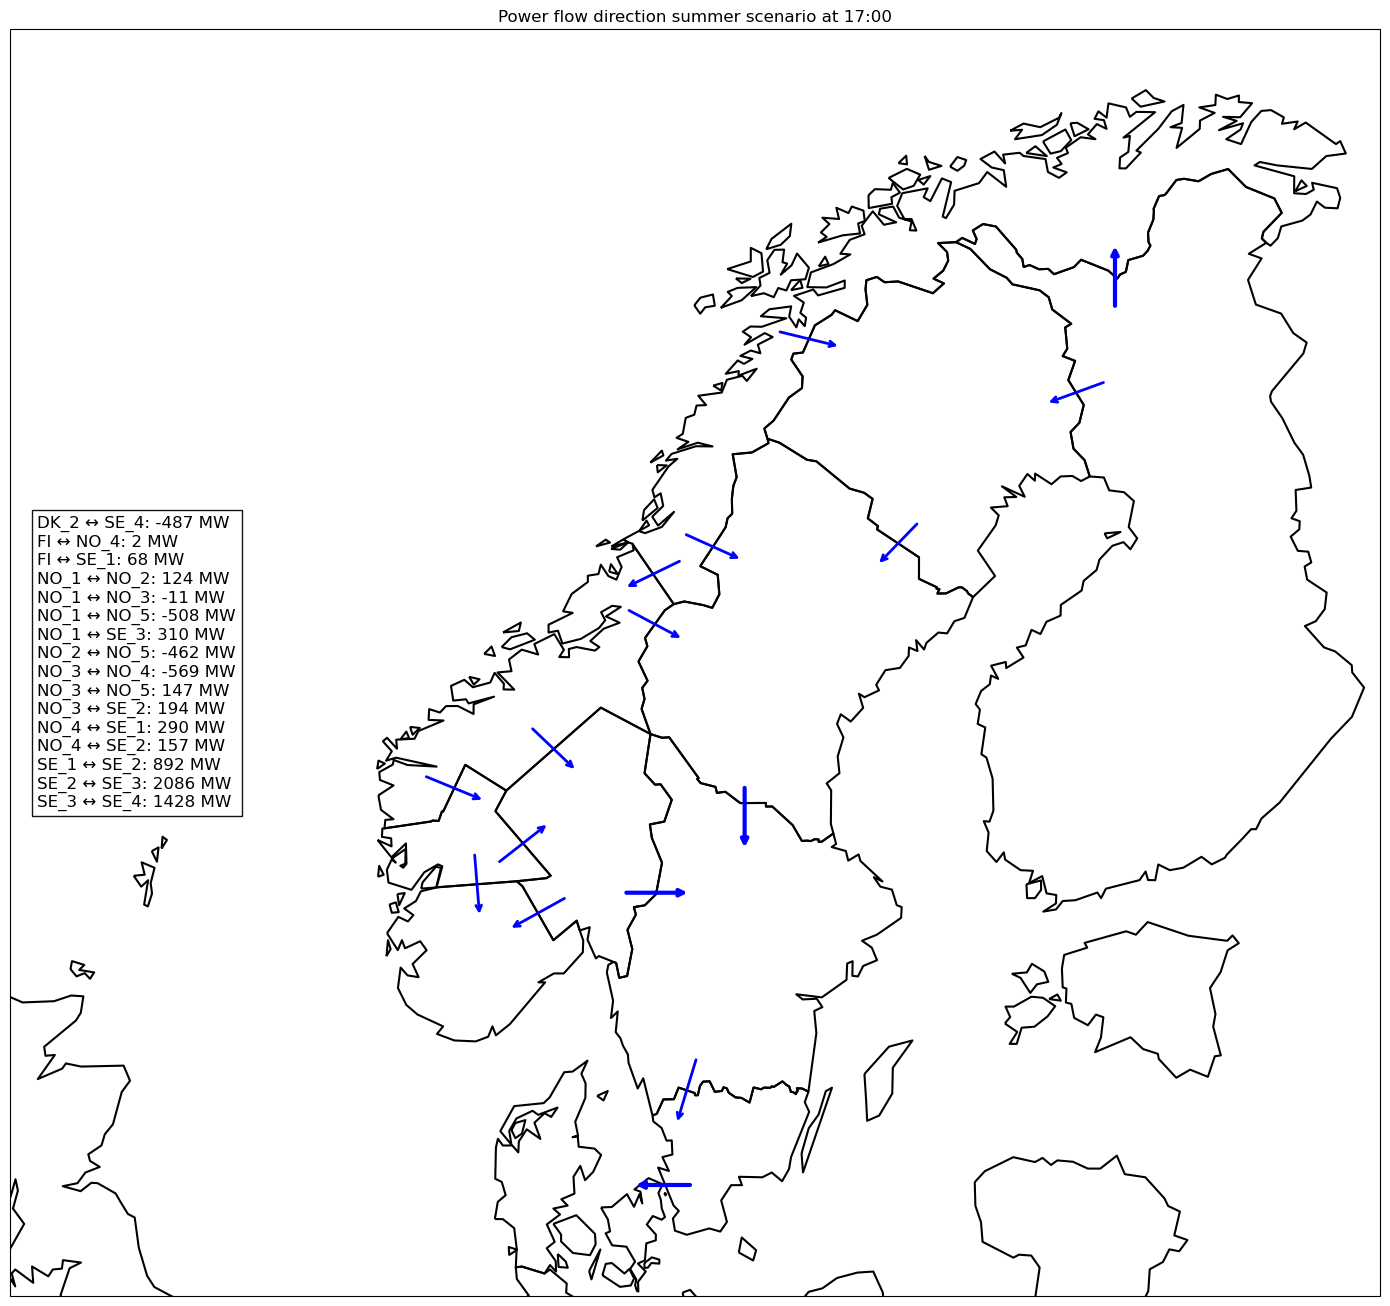

   zoneA zoneB   AC_flow_MW          lines_included
0   DK_2  SE_4  -486.677500                       0
1     FI  NO_4     2.230023                      12
2     FI  SE_1    68.136227                13, 8, 9
3   NO_1  NO_2   123.641334                  27, 29
4   NO_1  NO_3   -11.448275                      57
5   NO_1  NO_5  -507.535690                  18, 20
6   NO_1  SE_3   309.552631                      53
7   NO_2  NO_5  -461.921166                  52, 58
8   NO_3  NO_4  -568.961435                      43
9   NO_3  NO_5   146.816856                      31
10  NO_3  SE_2   193.606304                      59
11  NO_4  SE_1   289.687983                      34
12  NO_4  SE_2   157.160604                      42
13  SE_1  SE_2   891.514210              70, 89, 96
14  SE_2  SE_3  2086.481119      62, 73, 74, 78, 97
15  SE_3  SE_4  1428.297500  65, 81, 82, 83, 91, 92


In [38]:
flows = compute_crossborder_flows_ac_2(n, snapshot_index=17).reset_index()
zoneFlowPlot(flows, "Power flow direction summer scenario at 17:00", "bidding_zones.geojson")
print(flows)


In [39]:
n.generators.columns

Index(['bus', 'control', 'type', 'p_nom', 'p_nom_mod', 'p_nom_extendable',
       'p_nom_min', 'p_nom_max', 'p_min_pu', 'p_max_pu', 'p_set', 'e_sum_min',
       'e_sum_max', 'q_set', 'sign', 'carrier', 'marginal_cost',
       'marginal_cost_quadratic', 'active', 'build_year', 'lifetime',
       'capital_cost', 'efficiency', 'committable', 'start_up_cost',
       'shut_down_cost', 'stand_by_cost', 'min_up_time', 'min_down_time',
       'up_time_before', 'down_time_before', 'ramp_limit_up',
       'ramp_limit_down', 'ramp_limit_start_up', 'ramp_limit_shut_down',
       'weight', 'p_nom_opt', 'zone', 'production_share'],
      dtype='object')

In [40]:
# 7. Network summary and verification

print("=== NETWORK SUMMARY ===")
print(f"Buses: {len(n.buses)}")
print(f"Generators: {len(n.generators)}")
print(f"Links: {len(n.links)}")
print(f"Lines: {len(n.lines)}")
print(f"Loads: {len(n.loads)}")
print("\n=== NORDIC SYNC GRID BUSES ===")

"""nordic_sync_buses = ["DE", "NL"]
for bus in nordic_sync_buses:
    if bus in n.buses.index:
        print(f"✅ {bus}: {n.buses.loc[bus, 'v_nom']} kV")"""



print("\n=== SLACK GENERATORS ===")
slack_gens = (n.generators[n.generators['carrier'] == 'slack'])
print(f"Total slack generators: {len(slack_gens)}")
print("   - No p_nom specified (PyPSA handles automatically)")
print("   - DK_1 cleaned: all generators, loads, storage units removed")
print("   - One slack generator added to DK_1")

# Count buses per zone
bus_counts = n.buses['zone'].value_counts()

# Count generators per zone
gen_counts = n.generators['zone'].value_counts()

# Combine into one DataFrame
zone_summary = pd.DataFrame({
    'Number of Buses': bus_counts,
    'Number of Generators': gen_counts
}).fillna(0).astype(int)  # Fill missing with 0 and convert to int

# Sort by zone name (optional, for readability)
zone_summary = zone_summary.sort_index()

print(zone_summary)
print(n.generators[n.generators['control'] == 'Slack'])

=== NETWORK SUMMARY ===
Buses: 71
Generators: 466
Links: 14
Lines: 101
Loads: 64

=== NORDIC SYNC GRID BUSES ===

=== SLACK GENERATORS ===
Total slack generators: 8
   - No p_nom specified (PyPSA handles automatically)
   - DK_1 cleaned: all generators, loads, storage units removed
   - One slack generator added to DK_1
      Number of Buses  Number of Generators
zone                                       
DK_1                1                     1
DK_2                1                    10
FI                  9                    92
NO_1                5                    31
NO_2                8                    55
NO_3                6                    44
NO_4                6                    37
NO_5                3                    21
SE_1                4                    19
SE_2                5                    32
SE_3               13                    87
SE_4                4                    31
                   bus control type      p_nom  p_nom_mod  p_n

In [41]:
n.generators.carrier.unique


<bound method Series.unique of Generator
DK1 0 CCGT                         CCGT
DK1 0 biomass                   biomass
DK1 0 coal                         coal
FI1 0 CCGT                         CCGT
FI1 0 biomass                   biomass
FI1 0 coal                         coal
FI1 0 nuclear                   nuclear
FI1 0 oil                           oil
FI1 1 CCGT                         CCGT
FI1 1 biomass                   biomass
FI1 2 CCGT                         CCGT
FI1 2 biomass                   biomass
FI1 2 coal                         coal
FI1 2 nuclear                   nuclear
FI1 2 oil                           oil
FI1 3 CCGT                         CCGT
FI1 3 biomass                   biomass
FI1 4 biomass                   biomass
FI1 4 coal                         coal
FI1 4 oil                           oil
FI1 5 CCGT                         CCGT
FI1 5 biomass                   biomass
FI1 5 coal                         coal
FI1 5 oil                           oil